In [6]:
import pandas as pd
import numpy as np
import tkinter as tk
from PIL import Image, ImageTk

In [7]:
def get_digit_data(number, file_path, set_type, tunicate = False):

    # Load data
    df = pd.read_excel(file_path, sheet_name=f"a{set_type}", header=None)
    labels = pd.read_excel(file_path, sheet_name=f"d{set_type}", header=None).values.flatten()

    # Convert to numpy
    X = df.values  # shape: (256, N)

    # Find matching columns, create a boolean array where True indicates the column corresponds to the desired number
    # a numpy thing: we can directly compare the labels array to the number, resulting in a boolean array
    mask = labels == number

    if not mask.any():
        raise ValueError(f"Number {number} not found in dataset")

    # Select only those columns
    selected = X[:, mask]  # shape: (256, num_selected)

    # Transpose to (num_images, 256) → better format
    if tunicate:
        selected = selected.T

    return number, selected

In [ ]:
# visualization tool


file_path = "data.xlsx"

current_images = None
current_digit = None
index = 0

root = tk.Tk()
root.title("Digit Viewer")
window_width = 400
window_height = 400
screen_width = root.winfo_screenwidth()
screen_height = root.winfo_screenheight()

x = (screen_width // 2) - (window_width // 2)
y = (screen_height // 2) - (window_height // 2)

root.geometry(f"{window_width}x{window_height}+{x}+{y}")

# Input field
entry = tk.Entry(root, width=5, justify="center", font=("Arial", 14))
entry.pack(pady=5)

# Label for digit
digit_label = tk.Label(root, text="", font=("Arial", 20))
digit_label.pack(pady=5)

# Counter label
counter_label = tk.Label(root, text="")
counter_label.pack(pady=5)

# Image display
img_label = tk.Label(root)
img_label.pack(pady=10)

root.resizable(False, False)


def show_image():
    global index, current_images

    if current_images is None:
        return

    img_array = current_images[index].reshape(16, 16)

    # normalize
    img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min()) * 255
    img_array = img_array.astype(np.uint8)

    img = Image.fromarray(img_array).resize((200, 200))
    imgtk = ImageTk.PhotoImage(img)

    img_label.config(image=imgtk)
    img_label.image = imgtk

    digit_label.config(text=f"Digit: {current_digit}")
    counter_label.config(text=f"{index + 1} / {len(current_images)}")


def refresh():
    global current_images, current_digit, index

    try:
        digit = int(entry.get())
        current_digit, current_images = get_digit_data(digit, file_path, "zip", tunicate=True)
        index = 0
        show_image()
    except Exception as e:
        digit_label.config(text=str(e))
        counter_label.config(text="")
        img_label.config(image="")


def next_image():
    global index
    if current_images is not None and index < len(current_images) - 1:
        index += 1
        show_image()


def prev_image():
    global index
    if current_images is not None and index > 0:
        index -= 1
        show_image()


# Buttons
btn_frame = tk.Frame(root)
btn_frame.pack()

prev_btn = tk.Button(btn_frame, text="←", command=prev_image)
prev_btn.pack(side="left", padx=10)

next_btn = tk.Button(btn_frame, text="→", command=next_image)
next_btn.pack(side="left", padx=10)

refresh_btn = tk.Button(root, text="Refresh", command=refresh)
refresh_btn.pack(pady=10)

root.mainloop()

In [9]:
number, array = get_digit_data(1, file_path, "zip")
U, S, Vt = np.linalg.svd(array, full_matrices=False)


c:\Users\Dimit\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\Dimit\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


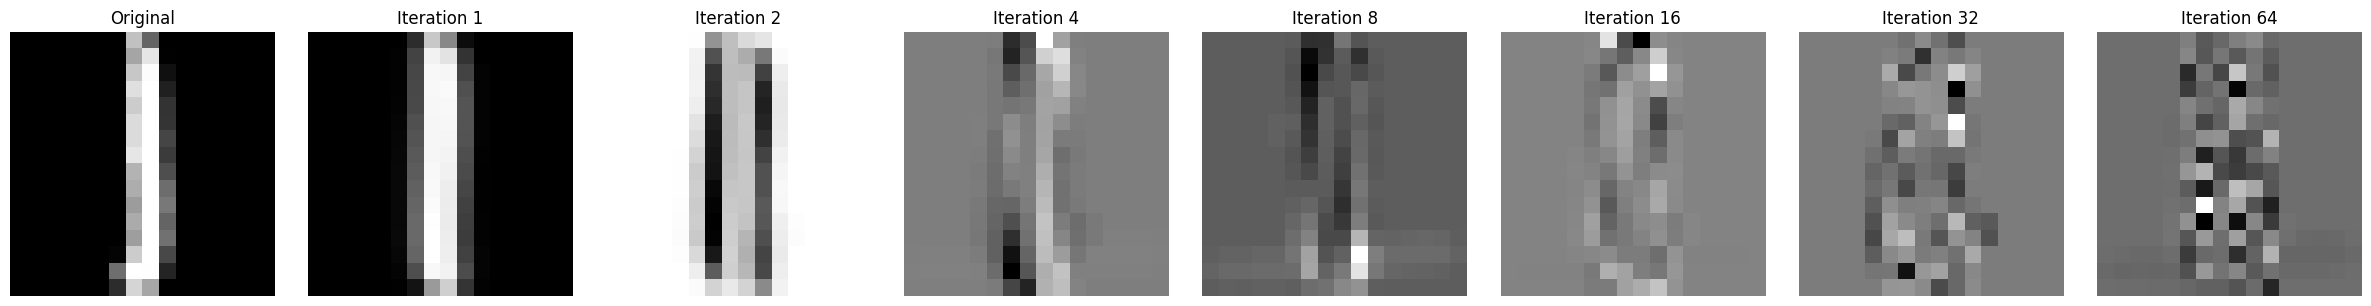

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Choose image
img_idx = 0
img_original = array[:, img_idx].reshape(16, 16)

# ranks you want to visualize
level_of_detail_by_σ = [1, 2, 4, 8, 16, 32, min(len(S), 64)]
level_of_detail_by_σ = sorted(set(k for k in level_of_detail_by_σ if k <= len(S)))

fig, axes = plt.subplots(
    1, len(level_of_detail_by_σ) + 1,
    figsize=(3 * (len(level_of_detail_by_σ) + 1), 3)
)

# Original
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

# Each image is ONLY one u_i * s_i * v_i^T
for j, k in enumerate(level_of_detail_by_σ, start=1):

    ui = U[:, k-1]                 # (256,)
    si = S[k-1]                    # scalar
    vi = Vt[k-1, img_idx]         # scalar (specific image coefficient)

    img_k = si * ui * vi          # rank-1 contribution
    img_k = img_k.reshape(16, 16)

    axes[j].imshow(img_k, cmap='gray')
    axes[j].set_title(f"Iteration {k}")
    axes[j].axis("off")

plt.tight_layout()
plt.show()